# Q1 GPS Quality Assessment

This notebook reads raw GPS observations from PostGIS and writes documented quality flags to a separate processed table. It does not alter or delete rows in `raw.gps_points_raw`.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(PROJECT_ROOT)

C:\Users\umary\Desktop\EHA test


## 1. Environment and connection setup

The notebook resolves the Q1 project directory from its own location, then loads database variables from the local, Git-ignored `src/.env.txt` file. Values are never displayed.

In [2]:
from __future__ import annotations

import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name != 'Q1_Campaign_Team_Tracking':
    try:
        PROJECT_ROOT = next(path for path in (PROJECT_ROOT, *PROJECT_ROOT.parents) if path.name == 'Q1_Campaign_Team_Tracking')
    except StopIteration as error:
        raise RuntimeError('Run this notebook from within Q1_Campaign_Team_Tracking.') from error

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.ingestion.db_connection import get_connection
from src.quality.gps_quality_rules import (
    CONFIG,
    build_flag_records,
    evaluate_gps_quality,
    quality_summary,
    upsert_quality_flags,
)

ENV_PATH = PROJECT_ROOT / 'src' / '.env.txt'
OUTPUT_PATH = PROJECT_ROOT / 'outputs' / 'tables' / 'gps_quality_summary.csv'

def load_environment_file(path: Path) -> None:
    if not path.is_file():
        raise FileNotFoundError(f'Local database environment file not found: {path}')
    for line in path.read_text(encoding='utf-8').splitlines():
        line = line.strip()
        if not line or line.startswith('#'):
            continue
        if '=' not in line:
            raise ValueError(f'Invalid environment entry in {path.name}: {line.split()[0]!r}')
        key, value = line.split('=', 1)
        os.environ[key.strip()] = value.strip().strip(chr(34)).strip(chr(39))

load_environment_file(ENV_PATH)
required_variables = ['POSTGRES_DB', 'POSTGRES_USER', 'POSTGRES_PASSWORD', 'POSTGRES_HOST', 'POSTGRES_PORT']
missing_variables = [name for name in required_variables if not os.environ.get(name)]
if missing_variables:
    raise RuntimeError('Missing required database variables: ' + ', '.join(missing_variables))

OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
print(f'Environment loaded from {ENV_PATH.name}; output path ready: {OUTPUT_PATH.relative_to(PROJECT_ROOT)}')

Environment loaded from .env.txt; output path ready: outputs\tables\gps_quality_summary.csv


## 2. Load raw GPS observations

The query intentionally applies no quality filters. Missing and anomalous values are retained so they can be represented as flags.

In [3]:
GPS_QUERY = '''
SELECT
    gps_track_point_id, source_file, team_id, logger_id, observed_at,
    longitude, latitude, accuracy_m, speed_kmh
FROM raw.gps_points_raw
ORDER BY team_id, logger_id, observed_at, gps_track_point_id
'''

with get_connection() as connection:
    gps_points = pd.read_sql_query(GPS_QUERY, connection)

if gps_points.empty:
    raise RuntimeError('No GPS observations are available in raw.gps_points_raw. Run GPS ingestion first.')

gps_points.head()

   gps_track_point_id         source_file  ... accuracy_m speed_kmh
0                   1  T01_2026-03-09.csv  ...       54.6      3.26
1                   2  T01_2026-03-09.csv  ...       14.8      3.88
2                   3  T01_2026-03-09.csv  ...       39.6      3.92
3                   4  T01_2026-03-09.csv  ...       52.2      3.26
4                   5  T01_2026-03-09.csv  ...       18.3      0.48

[5 rows x 9 columns]

## 3. Apply documented quality rules

Rules cover speed, accuracy, campaign hours, sequence gaps, and stationary clusters. Thresholds are documented in `src/quality/README.md` and are screening rules, not evidence that a point is invalid.

In [4]:
qa_points = evaluate_gps_quality(gps_points, CONFIG)
flag_records = build_flag_records(qa_points, CONFIG)
summary = quality_summary(flag_records, len(qa_points))
summary

                          Rule  flagged_records  percentage
0             impossible_speed             5612    0.586599
1  reported_speed_disagreement             1529    0.159820
2             accuracy_quality           415155   43.394390
3       outside_campaign_hours           773764   80.878267
4                      gps_gap              182    0.019024
5           stationary_cluster             8869    0.927039
6    source_file_date_mismatch           818397   85.543565

## 4. Store flags and export the quality summary

Only `processed.gps_quality_flags` and the project-relative summary CSV are written. The raw GPS table is not updated.

In [5]:
with get_connection() as connection:
    upsert_quality_flags(connection, flag_records)

summary.to_csv(OUTPUT_PATH, index=False)
print(f'Flag records written: {len(flag_records):,}')
print(f'Summary written: {OUTPUT_PATH.relative_to(PROJECT_ROOT)}')

Flag records written: 2,023,508
Summary written: outputs\tables\gps_quality_summary.csv


## 5. Diagnostic visualizations

These plots support QA review only. They are not final maps and do not make settlement-attribution or hotspot decisions.

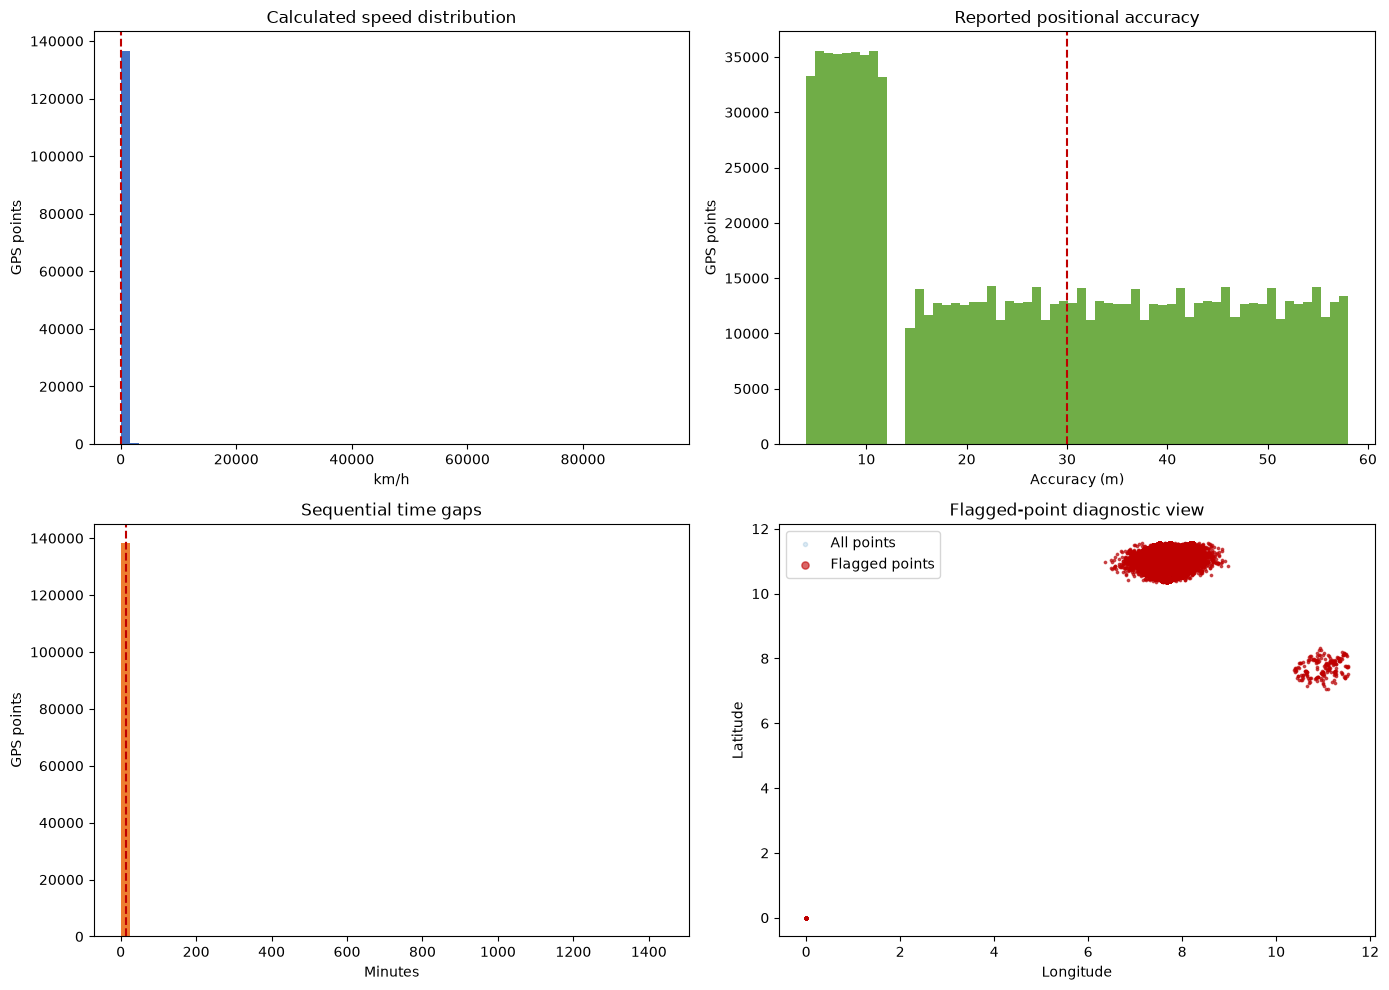

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(qa_points['calculated_speed_kmh'].dropna(), bins=60, color='#4472C4')
axes[0, 0].axvline(CONFIG.maximum_plausible_speed_kmh, color='#C00000', linestyle='--')
axes[0, 0].set(title='Calculated speed distribution', xlabel='km/h', ylabel='GPS points')

axes[0, 1].hist(qa_points['accuracy_m'].dropna(), bins=60, color='#70AD47')
axes[0, 1].axvline(CONFIG.maximum_acceptable_accuracy_m, color='#C00000', linestyle='--')
axes[0, 1].set(title='Reported positional accuracy', xlabel='Accuracy (m)', ylabel='GPS points')

axes[1, 0].hist(qa_points['sequence_gap_minutes'].dropna(), bins=60, color='#ED7D31')
axes[1, 0].axvline(CONFIG.sequence_gap_minutes, color='#C00000', linestyle='--')
axes[1, 0].set(title='Sequential time gaps', xlabel='Minutes', ylabel='GPS points')

rule_columns = ['impossible_speed_flag', 'accuracy_quality_flag', 'outside_campaign_hours_flag', 'gps_gap_flag', 'stationary_cluster_flag', 'source_file_date_mismatch_flag']
flagged_points = qa_points[qa_points[rule_columns].any(axis=1)]
axes[1, 1].scatter(qa_points['longitude'], qa_points['latitude'], s=1, alpha=0.15, label='All points')
axes[1, 1].scatter(flagged_points['longitude'], flagged_points['latitude'], s=3, alpha=0.6, color='#C00000', label='Flagged points')
axes[1, 1].set(title='Flagged-point diagnostic view', xlabel='Longitude', ylabel='Latitude')
axes[1, 1].legend(markerscale=3)
fig.tight_layout()

## 6. Interpretation boundary

The output of this phase is **flagged GPS observations with documented quality concerns**. This notebook does not remove points, choose settlement-attribution tolerances, run hotspot analysis, or create final maps.